In [9]:
import os
import json

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import generate_areas as ga
from fringe_class import Fringe, FringeList
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
dir_path = 'drop-211025-2'

img_paths = [dir_path + '/'+ f for f in os.listdir(dir_path) if f.endswith('.jpg')]
img_paths.sort()

In [3]:
select = ga.Select(img_paths[3])
roi_max = select.select_roi()
roi_min = select.select_roi()

path_roi = 'rois-2.txt'

with open(path_roi, 'w') as f:
    f.write(str(roi_max))
    f.write('\n')
    f.write(str(roi_min))

In [4]:
import ast

path_roi = 'rois-2.txt'
with open(path_roi, 'r') as f:
    roi_max = f.readline().strip()
    roi_min = f.readline().strip()

roi_max = ast.literal_eval(roi_max)
roi_min = ast.literal_eval(roi_min)

roi_min

(178, 326, 34, 6)

In [5]:
fringe_collection = []

for path in img_paths:
    select = ga.SelectRNGArea(path, roi_max = roi_max, roi_min = roi_min, num=50)
    select.get_random_rois()
    fringe_list = select.extract()
    fringe_collection.append(fringe_list)

## Filter out the lowest frequencies

In [6]:
collection_low_ftl = []

for fringe_list in fringe_collection:
    fringe_list_new = fringe_list.filter_low_frq(inplace=False, nl=2)
    collection_low_ftl.append(fringe_list_new)

print(collection_low_ftl[0].list_len)

50


## Using phase unwraping method

In [7]:
frq_collection = []

for lines in collection_low_ftl:
    num_peaks = lines.count_peaks_of_autocorr()
    num = [i-1 for i in num_peaks]
    lines.filter_low_frq(nl=num)
    lines_Wn = lines.filter_notch_Wn(border=4, updateWn=True, rel_h=0.5, nperseg_c=1, inplace=False)
    frqs = lines_Wn.get_frq(prefilter=False)
    frq_collection.append(frqs)

In [8]:
means = [np.mean(frq) for frq in frq_collection]
stds = [np.std(frq) for frq in frq_collection]

means_f = [f"{m:.4f}" for m in means]
stds_f = [f"{s:.4f}" for s in stds]
print(means_f)
print(stds_f)

['1.5651', '1.4709', '1.3728', '1.2918', '1.2191', '1.1549', '1.1008', '1.0519', '1.0107', '0.9601', '0.9228', '0.8837', '0.8506', '0.8235']
['0.0431', '0.0324', '0.0484', '0.0282', '0.0289', '0.0268', '0.0253', '0.0259', '0.0326', '0.0202', '0.0249', '0.0293', '0.0216', '0.0184']


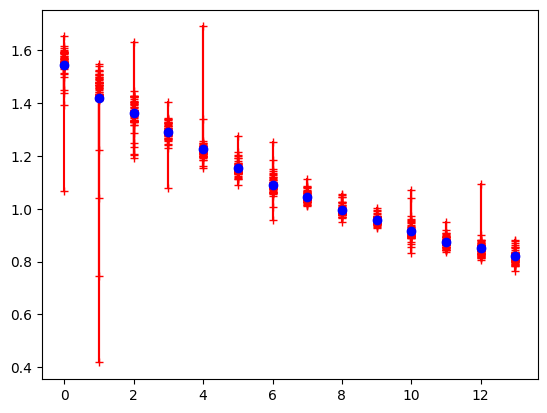

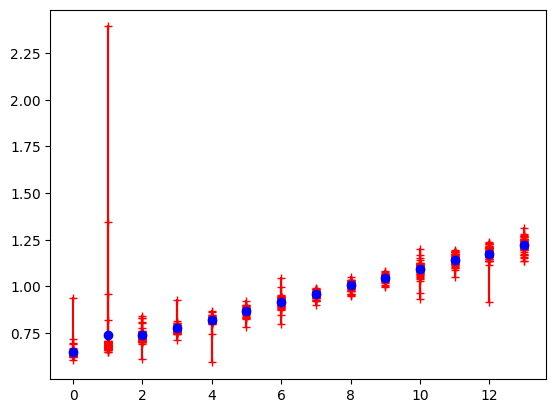

In [27]:
plt.figure()

for i, frqs in enumerate(frq_collection):
    T = [1/f for f in frqs]
    plt.plot([i]*len(frqs),T, color='red', marker = '+')
    plt.plot(i, np.mean(T), color='blue', marker='o')

plt.show()